In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
# 1. Load and Scale Data (Crucial for K-Means)
df = pd.read_csv('telemetry_log.csv')
X = df[['cpu_load', 'temperature']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
plt.plot(range(1, 7), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

NameError: name 'wcss' is not defined

In [4]:
# 3. Final Clustering (using K=3 for Stable/Warning/Critical)
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_transform(X_scaled).argmax(axis=1)

c:\Users\sahil\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\sahil\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\sahil\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\sahil\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

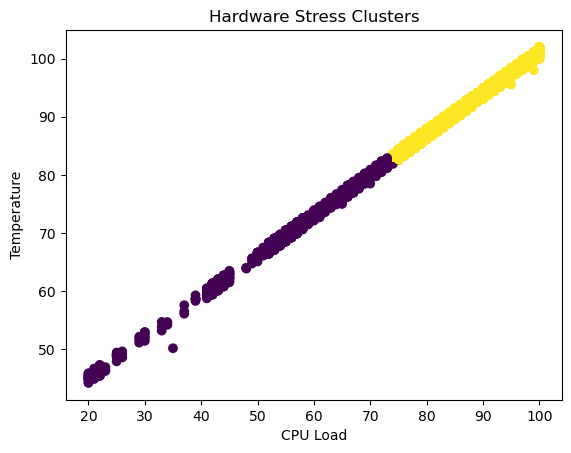

In [5]:
# 4. Visualizing Clusters
plt.scatter(df['cpu_load'], df['temperature'], c=df['cluster'], cmap='viridis')
plt.title('Hardware Stress Clusters')
plt.xlabel('CPU Load')
plt.ylabel('Temperature')
plt.show()